# Exploratory Data Analysis (EDA)

In [1]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
# Apply settings
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")

In [3]:
# Load cleaned data
data = pd.read_csv("../data/cleaned_data.csv")

In [4]:
# Backup
df = data.copy()

In [5]:
## Dataset overview
print("Dataset shape:", data.shape)
df.info()

Dataset shape: (1064, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       1064 non-null   object 
 1   Model         1064 non-null   object 
 2   FuelType      1063 non-null   object 
 3   Kilometer     1064 non-null   int64  
 4   ModelYear     1064 non-null   int64  
 5   Owner         1064 non-null   object 
 6   Warranty      1064 non-null   int64  
 7   QualityScore  1064 non-null   float64
 8   Price         1064 non-null   int64  
 9   CarAge        1064 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 83.3+ KB


In [6]:
# Column details
all_cols = df.columns.to_list()
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in df.select_dtypes(include="object") if c != "Price"]

print("All columns: \n", all_cols)
print("\nNumeric Columns: \n", numeric_cols)
print("\nCategorical Columns: \n", categorical_cols)

All columns: 
 ['Company', 'Model', 'FuelType', 'Kilometer', 'ModelYear', 'Owner', 'Warranty', 'QualityScore', 'Price', 'CarAge']

Numeric Columns: 
 ['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'Price', 'CarAge']

Categorical Columns: 
 ['Company', 'Model', 'FuelType', 'Owner']


In [7]:
# Null values
print("Null Count Summary: \n")
df.isnull().sum()

Null Count Summary: 



Company         0
Model           0
FuelType        1
Kilometer       0
ModelYear       0
Owner           0
Warranty        0
QualityScore    0
Price           0
CarAge          0
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer

# Categorical imputer: replace NaNs with most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])


In [9]:
# Null values
print("Null Count Summary: \n")
df.isnull().sum()

Null Count Summary: 



Company         0
Model           0
FuelType        0
Kilometer       0
ModelYear       0
Owner           0
Warranty        0
QualityScore    0
Price           0
CarAge          0
dtype: int64

In [10]:
# Column details
all_cols = df.columns.to_list()
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in df.select_dtypes(include="object") if c != "Price"]

print("All columns: \n", all_cols)
print("\nNumeric Columns: \n", numeric_cols)
print("\nCategorical Columns: \n", categorical_cols)

All columns: 
 ['Company', 'Model', 'FuelType', 'Kilometer', 'ModelYear', 'Owner', 'Warranty', 'QualityScore', 'Price', 'CarAge']

Numeric Columns: 
 ['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'Price', 'CarAge']

Categorical Columns: 
 ['Company', 'Model', 'FuelType', 'Owner']


### Target Variable Analysis
#### (Why? Price is almost always right-skewed in car datasets. Log transform helps models perform better.)

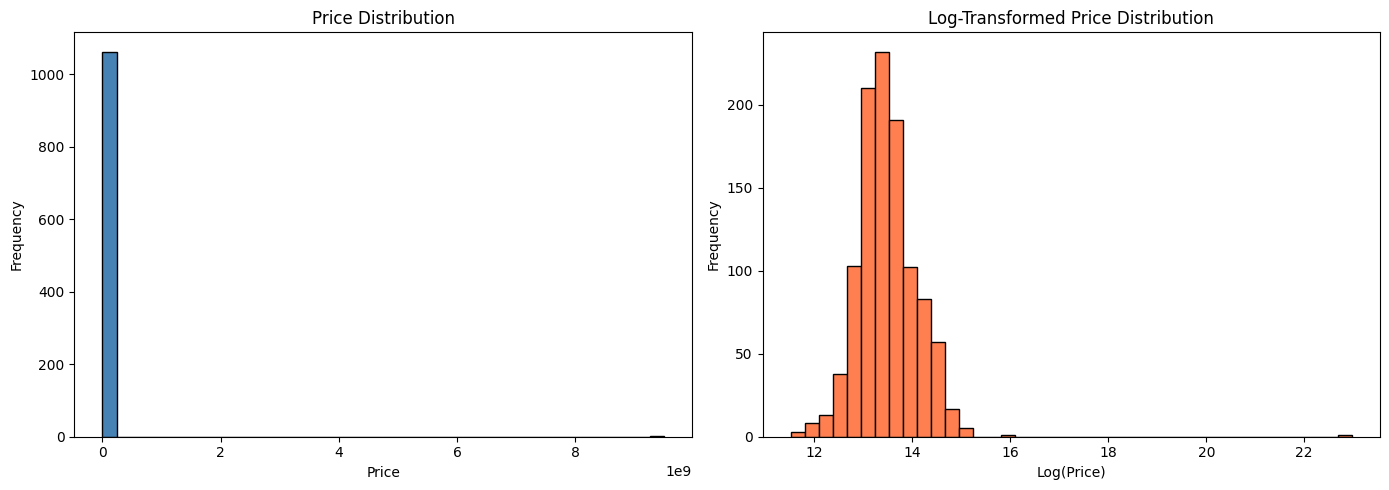

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['Price'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Log-transformed (useful if Price is skewed)
axes[1].hist(np.log1p(df['Price']), bins=40, color='coral', edgecolor='black')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

 ### Univariate — Numerical Features

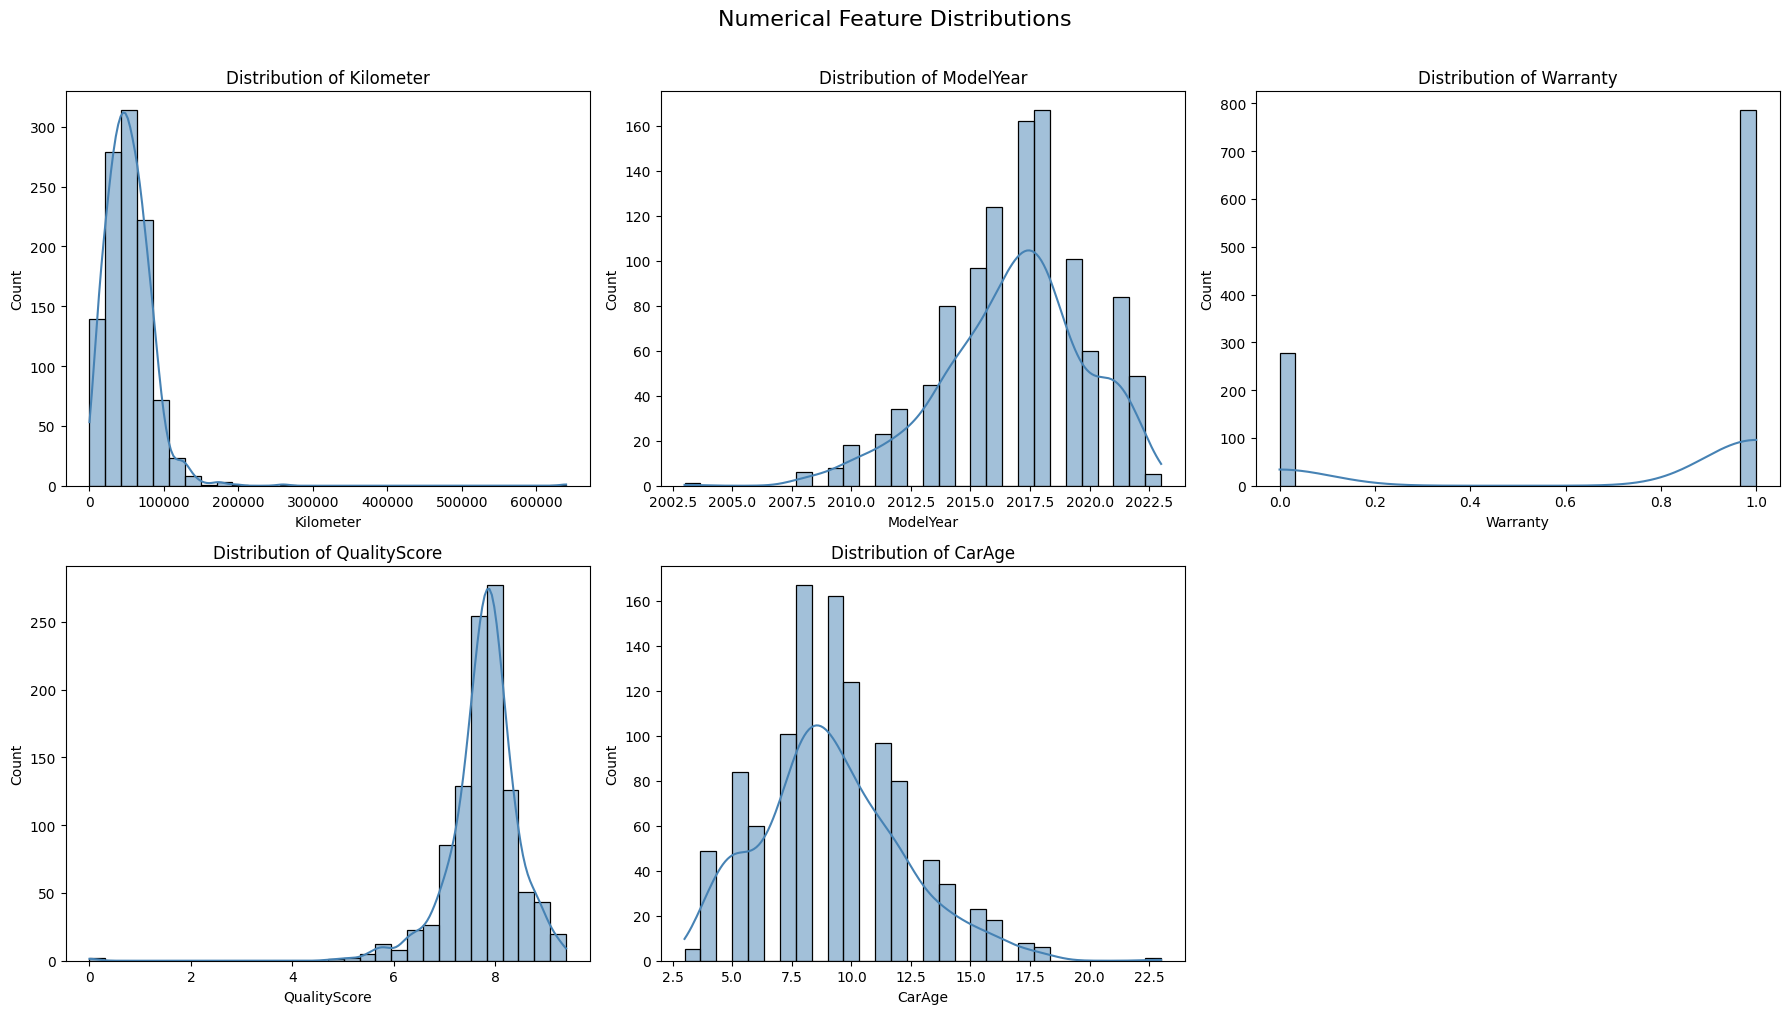

In [12]:
num_cols = ['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'CarAge']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

axes[5].set_visible(False)  # hide empty last subplot
plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Univariate — Categorical Features

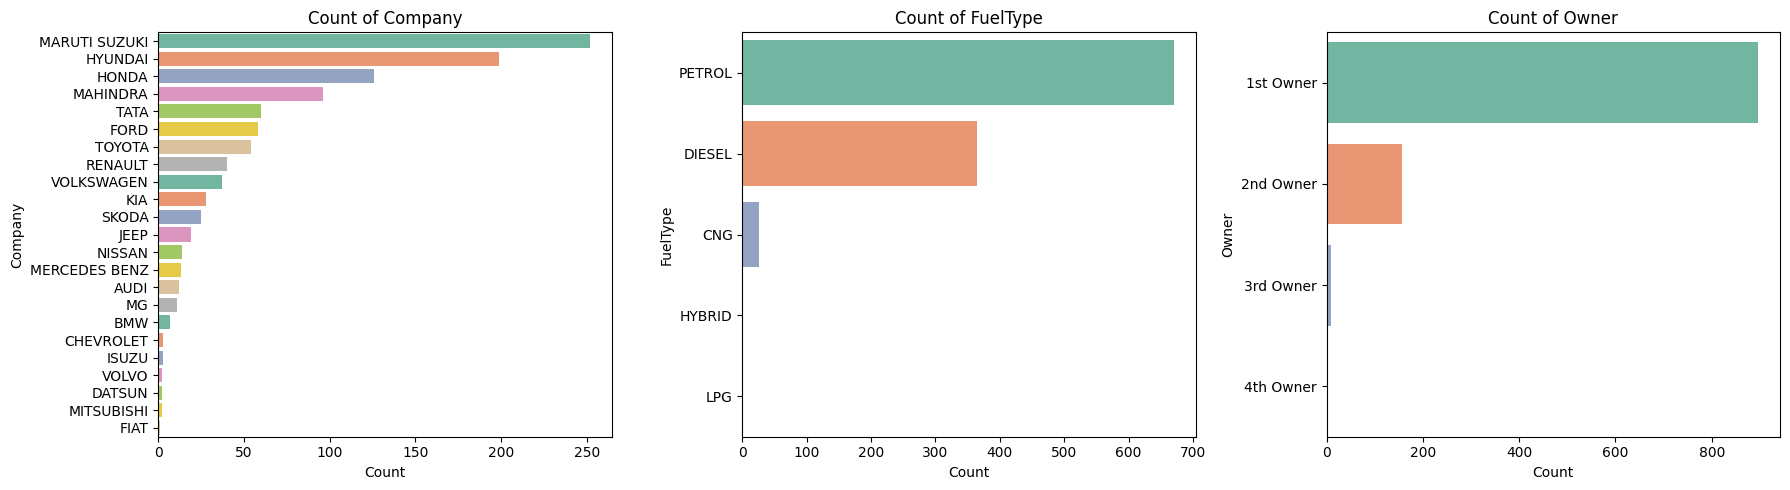

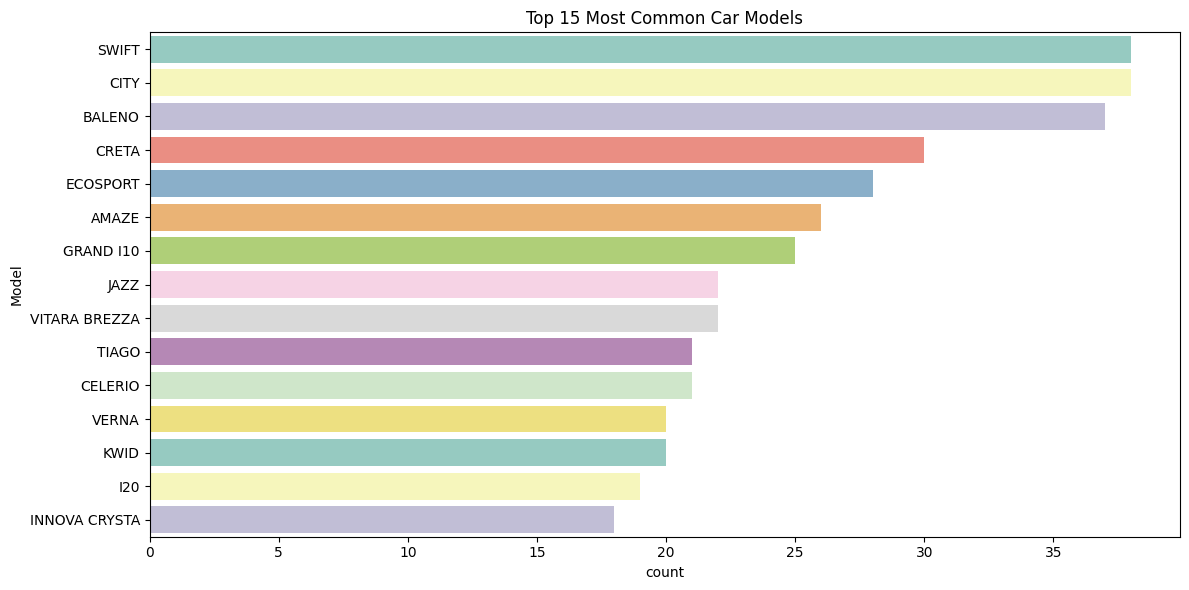

In [13]:
cat_cols = ['Company', 'FuelType', 'Owner']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=axes[i], order=order, palette='Set2')
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Top 15 Models separately (too many categories for standard plot)
plt.figure(figsize=(12, 6))
top_models = df['Model'].value_counts().head(15).index
sns.countplot(y='Model', data=df[df['Model'].isin(top_models)],
              order=top_models, palette='Set3')
plt.title('Top 15 Most Common Car Models')
plt.tight_layout()
plt.show()

### Bivariate — Numerical vs Price (Scatter + Regression Line)

### What to look for: Kilometer & CarAge → negative correlation. QualityScore → positive correlation.

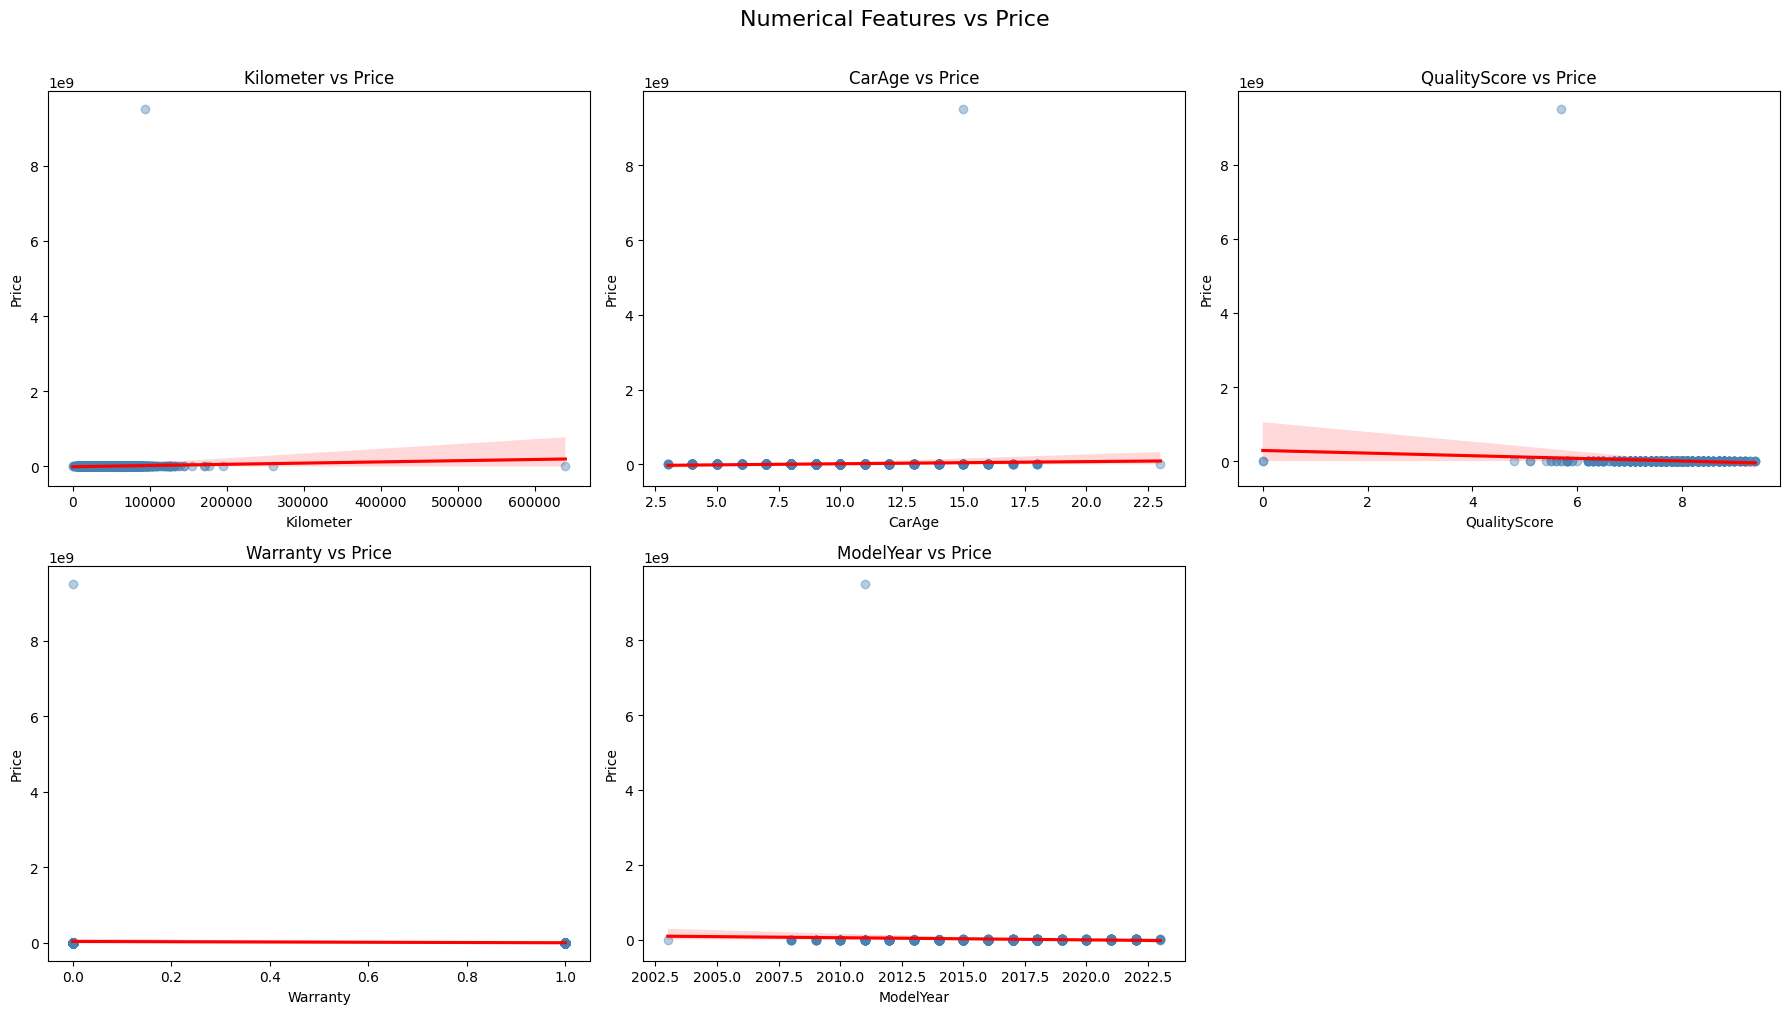

In [14]:
num_cols = ['Kilometer', 'CarAge', 'QualityScore', 'Warranty', 'ModelYear']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.regplot(x=col, y='Price', data=df, ax=axes[i],
                scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
                line_kws={'color': 'red'})
    axes[i].set_title(f'{col} vs Price')

axes[5].set_visible(False)
plt.suptitle('Numerical Features vs Price', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Bivariate — Categorical vs Price (Box Plots)


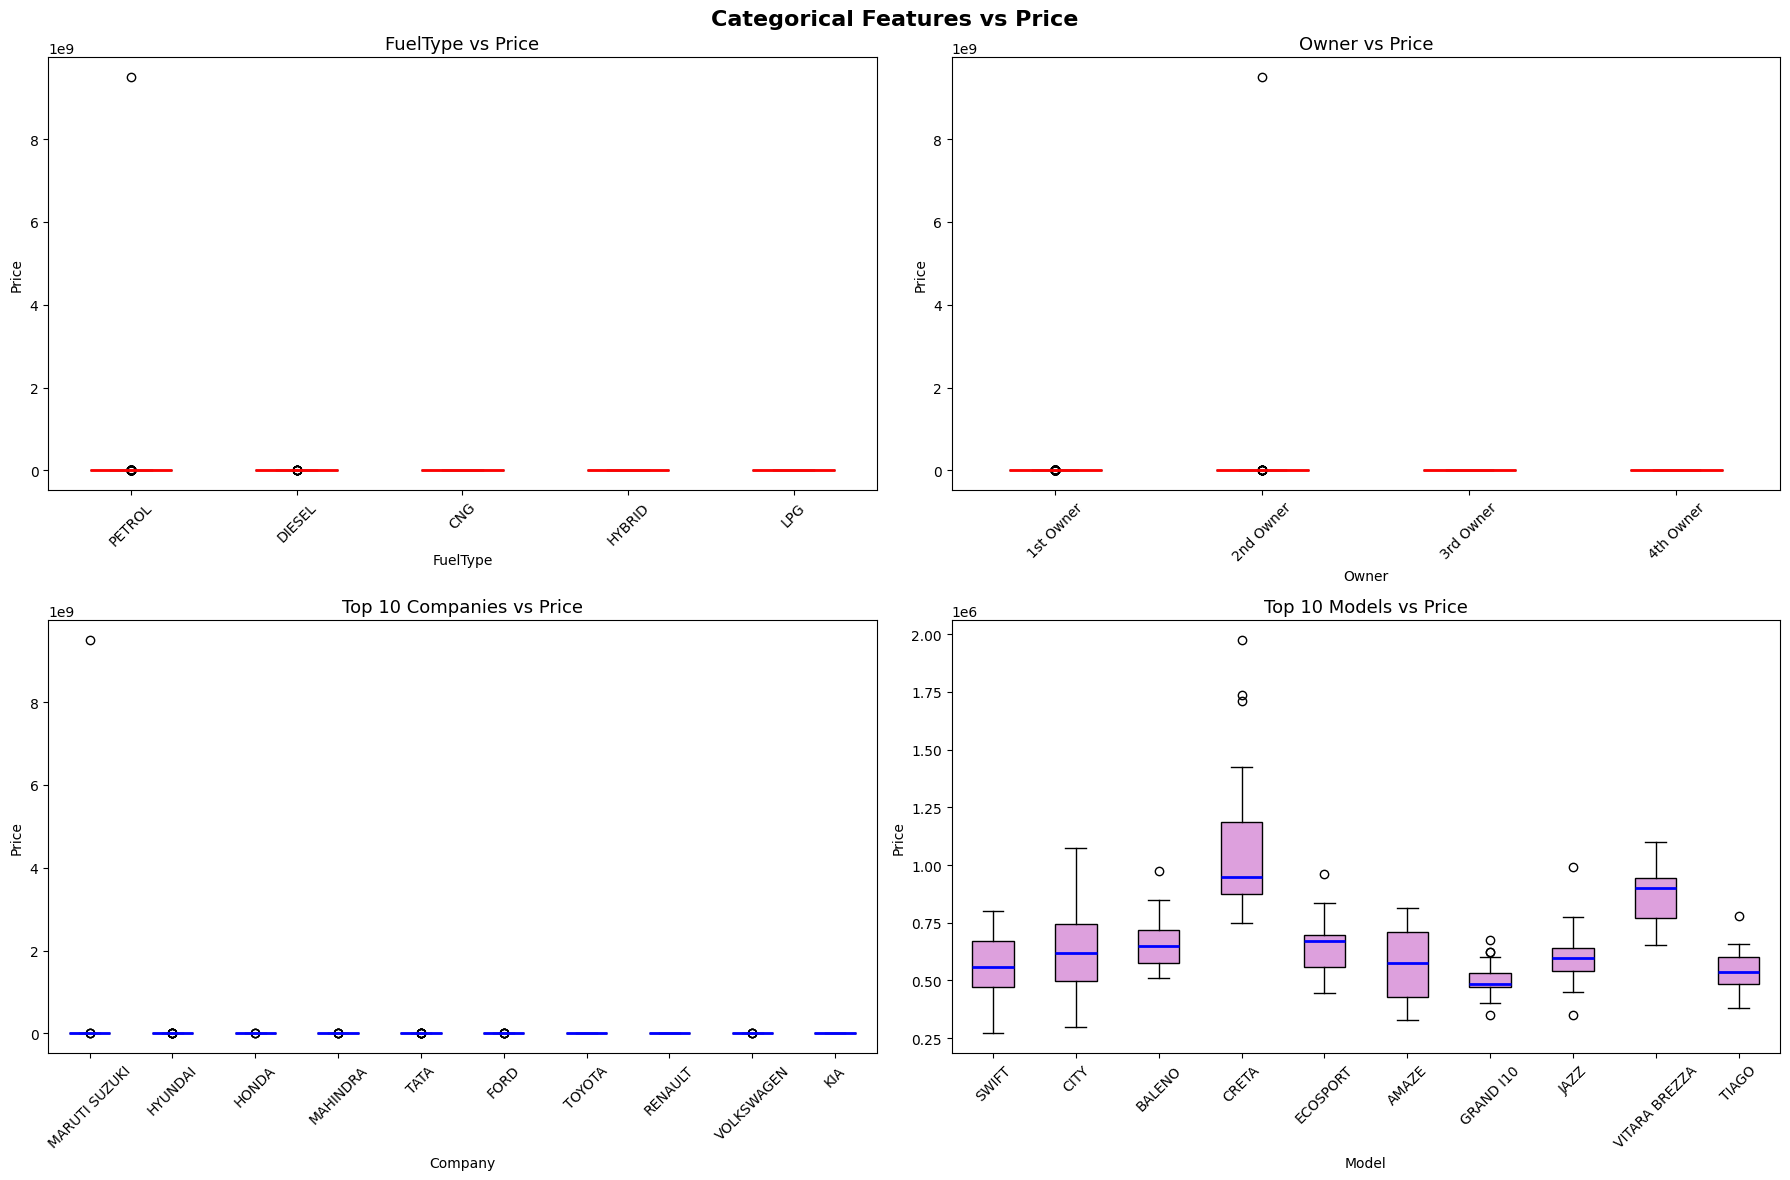

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── 1. FuelType vs Price ──────────────────────────────────────────
fuel_groups = [df[df['FuelType'] == ft]['Price'].dropna() for ft in df['FuelType'].unique()]
fuel_labels  = df['FuelType'].unique()

axes[0][0].boxplot(fuel_groups, labels=fuel_labels, patch_artist=True,
                   boxprops=dict(facecolor='skyblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[0][0].set_title('FuelType vs Price', fontsize=13)
axes[0][0].set_xlabel('FuelType')
axes[0][0].set_ylabel('Price')
axes[0][0].tick_params(axis='x', rotation=45)

# ── 2. Owner vs Price ─────────────────────────────────────────────
owner_order  = df['Owner'].value_counts().index.tolist()
owner_groups = [df[df['Owner'] == o]['Price'].dropna() for o in owner_order]

axes[0][1].boxplot(owner_groups, labels=owner_order, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen'),
                   medianprops=dict(color='red', linewidth=2))
axes[0][1].set_title('Owner vs Price', fontsize=13)
axes[0][1].set_xlabel('Owner')
axes[0][1].set_ylabel('Price')
axes[0][1].tick_params(axis='x', rotation=45)

# ── 3. Top 10 Companies vs Price ──────────────────────────────────
top_companies  = df['Company'].value_counts().head(10).index.tolist()
company_groups = [df[df['Company'] == c]['Price'].dropna() for c in top_companies]

axes[1][0].boxplot(company_groups, labels=top_companies, patch_artist=True,
                   boxprops=dict(facecolor='salmon'),
                   medianprops=dict(color='blue', linewidth=2))
axes[1][0].set_title('Top 10 Companies vs Price', fontsize=13)
axes[1][0].set_xlabel('Company')
axes[1][0].set_ylabel('Price')
axes[1][0].tick_params(axis='x', rotation=45)

# ── 4. Top 10 Models vs Price ─────────────────────────────────────
top_models  = df['Model'].value_counts().head(10).index.tolist()
model_groups = [df[df['Model'] == m]['Price'].dropna() for m in top_models]

axes[1][1].boxplot(model_groups, labels=top_models, patch_artist=True,
                   boxprops=dict(facecolor='plum'),
                   medianprops=dict(color='blue', linewidth=2))
axes[1][1].set_title('Top 10 Models vs Price', fontsize=13)
axes[1][1].set_xlabel('Model')
axes[1][1].set_ylabel('Price')
axes[1][1].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Price', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Outlier Detection — Box Plots

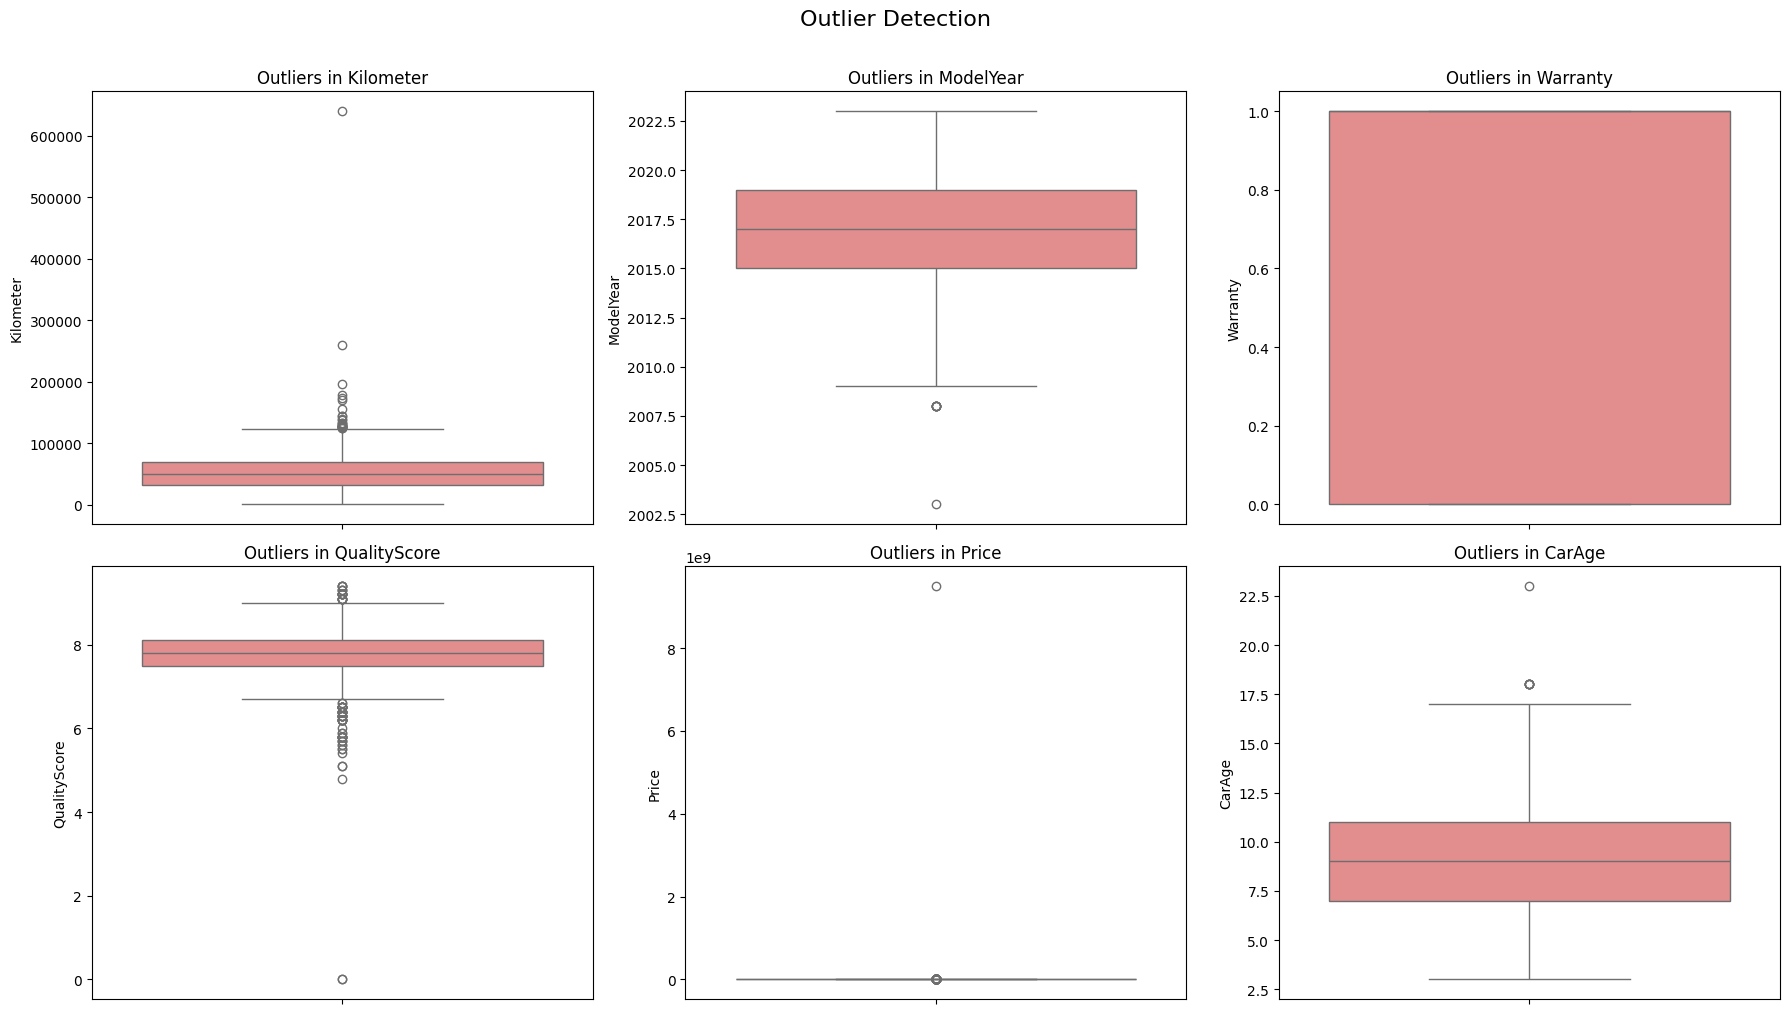

In [18]:
num_cols = ['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'Price', 'CarAge']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outliers in {col}')

plt.suptitle('Outlier Detection', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Check HOW MANY outliers exist in each column
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({round(len(outliers)/len(df)*100, 2)}%)")

Kilometer: 24 outliers (2.26%)
ModelYear: 7 outliers (0.66%)
Warranty: 0 outliers (0.0%)
QualityScore: 75 outliers (7.05%)
Price: 85 outliers (7.99%)
CarAge: 7 outliers (0.66%)


### Correlation Heatmap

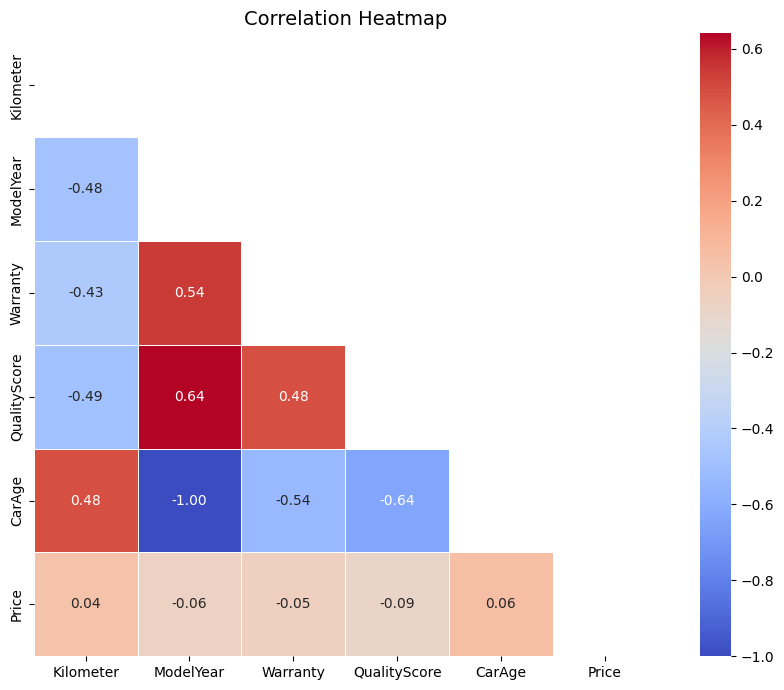

In [22]:
plt.figure(figsize=(9, 7))

corr = df[['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'CarAge', 'Price']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            mask=np.triu(np.ones_like(corr, dtype=bool)))  # triangle heatmap

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### Average Price by Category (Bar Charts)

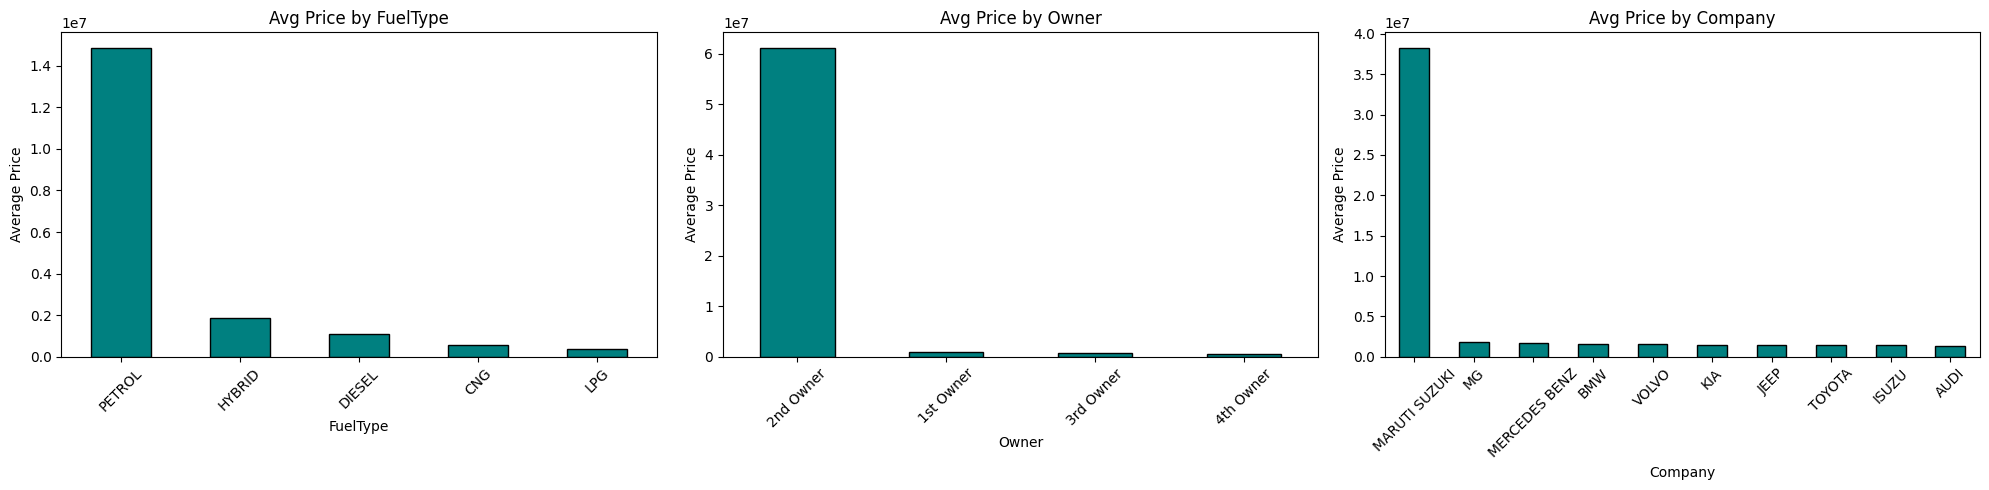

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(['FuelType', 'Owner', 'Company']):
    if col == 'Company':
        avg = df.groupby(col)['Price'].mean().sort_values(ascending=False).head(10)
    else:
        avg = df.groupby(col)['Price'].mean().sort_values(ascending=False)

    avg.plot(kind='bar', ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'Avg Price by {col}')
    axes[i].set_ylabel('Average Price')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()